# **Iphone Purchase Records Prediction** | 2025

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

- encode gender
- feature scaling 
- liat imbalance class > klo ada langsung di data sampling/smote

## ***B. Import Libraries***

In [510]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## ***C. Import Dataset***

In [511]:
dataset = pd.read_csv('iphone_purchase_records.csv')

# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [512]:
dataset.columns

Index(['Gender', 'Age', 'Salary', 'Purchase Iphone'], dtype='object')

Pengertian masing-masing variabel:
1. Gender = jenis kelamin pembeli
2. Age = umur pembeli
3. Salary = gaji pembeli
4. Purchase Iphone (target) = mereka beli ip apa ngga (0 = engga, 1 = iya)

### 2. Inspeksi Informasi Ringkas

In [513]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   Salary           400 non-null    int64 
 3   Purchase Iphone  400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB


In [514]:
all_feature = ["Gender", "Age", "Salary"]

### 3. Inspeksi Statistik Deskriptif

In [515]:
dataset.describe()

,Age,Salary,Purchase Iphone
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


### 4. Inspeksi Data NaN

In [516]:
dataset.isna().sum()

Gender             0
Age                0
Salary             0
Purchase Iphone    0
dtype: int64

### 5. Inspeksi Data Duplicated

In [517]:
dataset.duplicated().sum()

np.int64(20)

### 6. Univariate Analysis 

C:\Users\USER\AppData\Local\Temp\ipykernel_24680\1324590430.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Purchase Iphone", data=dataset, palette="coolwarm")


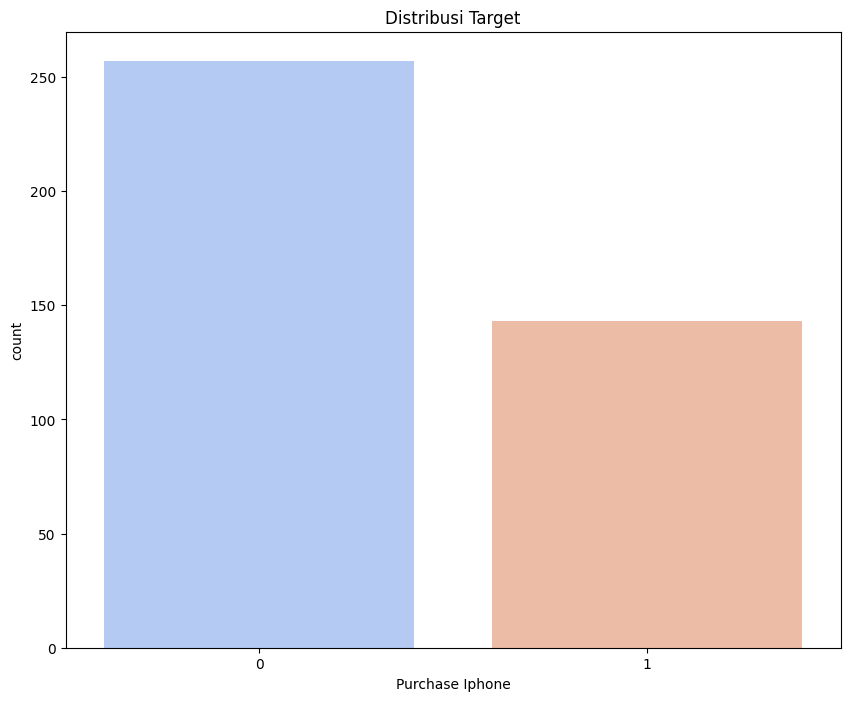

In [518]:
plt.figure(figsize=(10,8))
sns.countplot(x="Purchase Iphone", data=dataset, palette="coolwarm")
plt.title("Distribusi Target")
plt.show()

In [519]:
def check_value(cols):
    for col in cols:
        print(f"Kolom: {col}")
        print(dataset[col].value_counts())
        print("\n")

check_value(all_feature)

Kolom: Gender
Gender
Female    204
Male      196
Name: count, dtype: int64


Kolom: Age
Age
35    32
37    20
26    16
42    16
41    16
39    15
40    15
48    14
47    14
27    13
38    13
36    12
46    12
28    12
30    11
31    11
49    10
29    10
32     9
24     9
33     9
60     7
45     7
19     7
59     7
20     7
25     6
52     6
58     6
23     6
34     6
18     5
22     5
57     5
53     5
21     4
54     4
50     4
55     3
51     3
56     3
43     3
44     2
Name: count, dtype: int64


Kolom: Salary
Salary
72000     12
80000     11
79000     10
75000      9
71000      9
          ..
99000      1
129000     1
46000      1
64000      1
139000     1
Name: count, Length: 117, dtype: int64




### 7. Bivariate Analysis

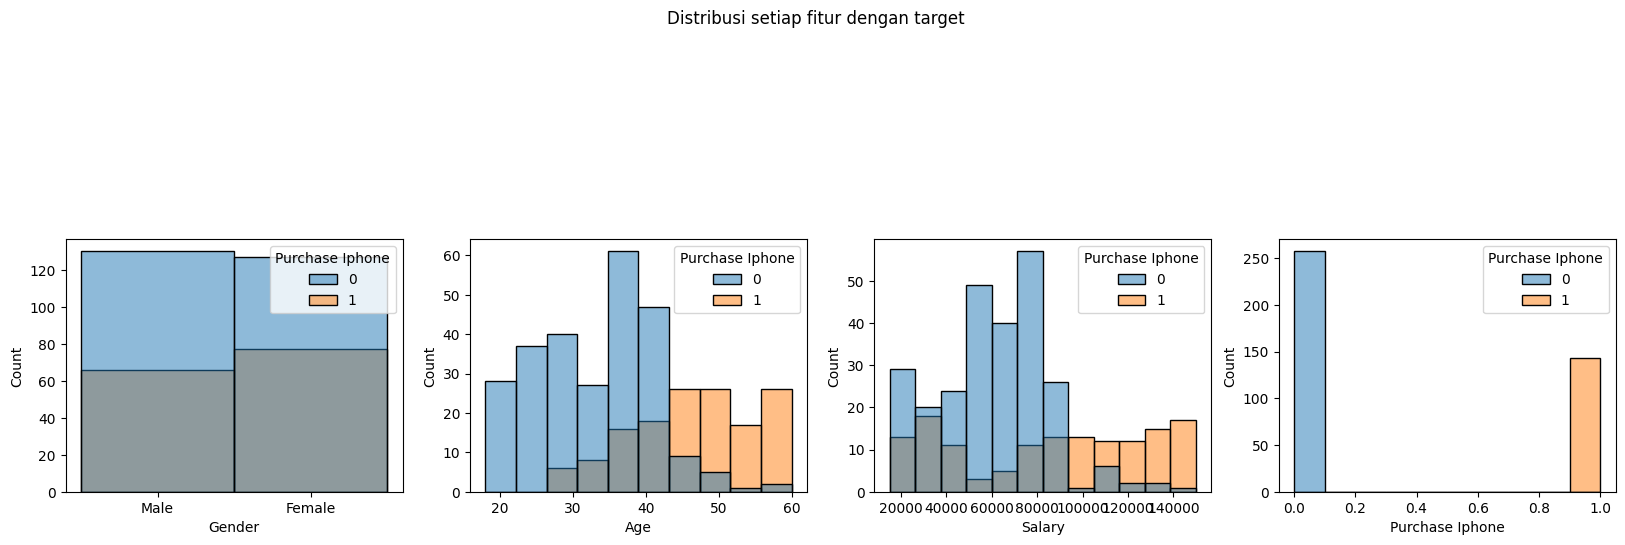

In [520]:
plt.figure(figsize=(20, 19))
for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["Purchase Iphone"])

plt.suptitle("Distribusi setiap fitur dengan target", y=1.001)
plt.tight_layout
plt.show()

### 8. Encoding

In [521]:
dataset = dataset.drop_duplicates()
map_gender = {'Male': 1, 'Female': 0}

dataset['Gender'] = dataset['Gender'].map(map_gender)

### 9. Inspeksi Korelasi

#### *a. Mutual Information*

In [522]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

fitur = dataset[all_feature]
target = dataset["Purchase Iphone"]

mi_scores = {col : mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

C:\Users\USER\AppData\Local\Temp\ipykernel_24680\3044783840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\USER\AppData\Local\Temp\ipykernel_24680\3044783840.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


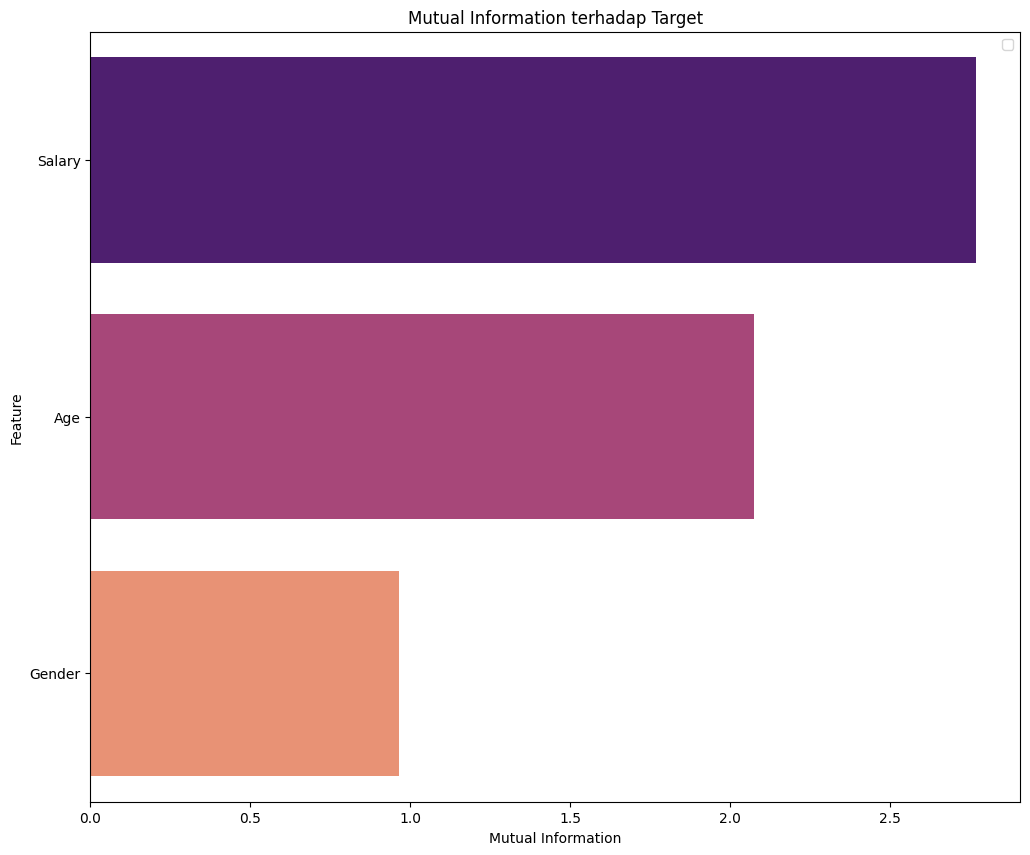

In [523]:
plt.figure(figsize=(12,10))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information terhadap Target")
plt.legend()
plt.show()

In [524]:
mi_df

,Feature,Mutual Information
2,Salary,2.769433
1,Age,2.073368
0,Gender,0.965043


#### *b. Kendall*


Kendall Correlation Matrix:
Purchase Iphone    1.000000
Age                0.513419
Salary             0.269214
Gender            -0.044257
Name: Purchase Iphone, dtype: float64


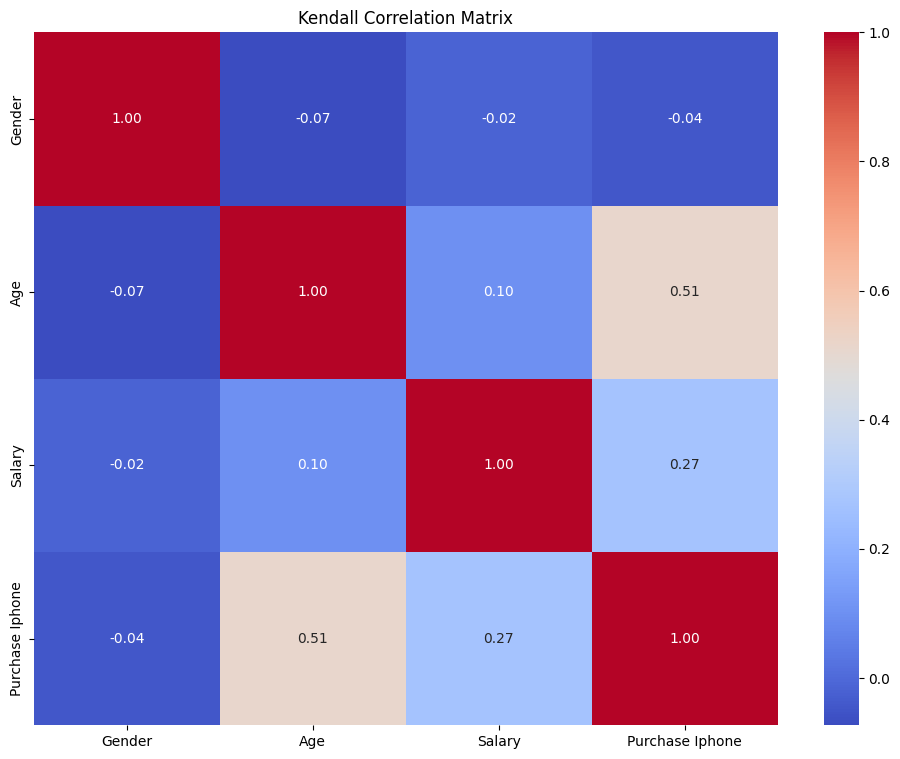

In [525]:
kendall_corr = dataset.corr(method="kendall")
print("\nKendall Correlation Matrix:")
print(kendall_corr["Purchase Iphone"].sort_values(ascending=False))

plt.figure(figsize=(12,9))
sns.heatmap(kendall_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Kendall Correlation Matrix")
plt.show()

#### *c. ANOVA*

In [526]:
def anova_f_test_manual(data, all_feature, target_col):
    group0 = data[data[target_col] == 0][all_feature].dropna()
    group1 = data[data[target_col] == 1][all_feature].dropna()

    n0 = len(group0)
    n1 = len(group1)
    if n0 == 0 or n1 == 0:
        return 0.0
    
    mean0 = group0.mean()
    mean1 = group1.mean()
    overall_mean = data[all_feature].mean()

    ssb = n0 * (mean0 - overall_mean)**2 + n1 * (mean1 - overall_mean)**2
    ssw = ((group0 - mean0)**2).sum() + ((group1 - mean1)**2).sum()

    df_between = 1
    df_within = n0 + n1 - 2

    if df_within == 0:
        return 0.0
    
    msb = ssb / df_between
    msw = ssw / df_within

    f_score = msb / msw if msw != 0 else 0.0

    return f_score

numerical_features = ['Age', 'Salary']
target_col = 'Purchase Iphone'

anova_scores = []
for col in numerical_features:
    score = anova_f_test_manual(dataset, col, target_col)
    anova_scores.append({'Feature': col, 'F_Score': score})

anova_df = pd.DataFrame(anova_scores).sort_values('F_Score', ascending=False)

C:\Users\USER\AppData\Local\Temp\ipykernel_24680\3678698399.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dataset, x='Purchase Iphone', y=col, ax=axes[i], palette='Pastel1', inner='quartile')
C:\Users\USER\AppData\Local\Temp\ipykernel_24680\3678698399.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dataset, x='Purchase Iphone', y=col, ax=axes[i], palette='Pastel1', inner='quartile')
C:\Users\USER\AppData\Local\Temp\ipykernel_24680\3678698399.py:10: UserWarning: Glyph 127931 (\N{VIOLIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\s

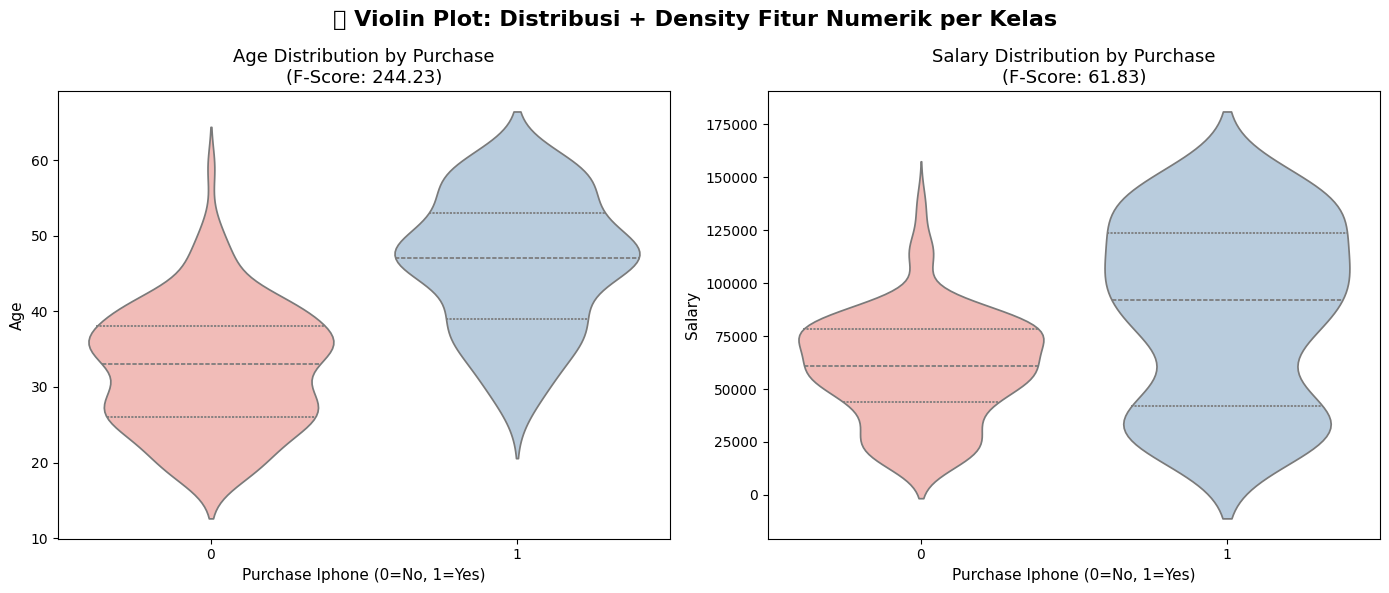

In [527]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, col in enumerate(numerical_features):
    sns.violinplot(data=dataset, x='Purchase Iphone', y=col, ax=axes[i], palette='Pastel1', inner='quartile')
    axes[i].set_title(f'{col} Distribution by Purchase\n(F-Score: {anova_df[anova_df["Feature"]==col]["F_Score"].values[0]:.2f})', fontsize=13)
    axes[i].set_xlabel('Purchase Iphone (0=No, 1=Yes)', fontsize=11)
    axes[i].set_ylabel(col, fontsize=11)

plt.suptitle('🎻 Violin Plot: Distribusi + Density Fitur Numerik per Kelas', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

### 10. Inspeksi Outlier

<Axes: xlabel='Purchase Iphone', ylabel='Salary'>

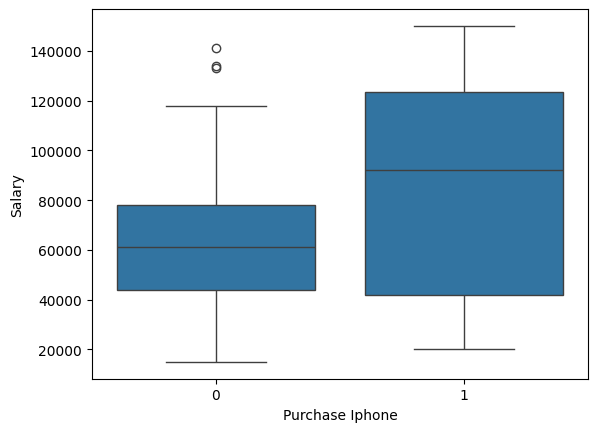

In [528]:
sns.boxplot(data=dataset, x="Purchase Iphone", y="Salary")

## ***B. Feature Selection***

In [529]:
features_cols = ['Salary', 'Age', 'Gender']

## ***C. Data Preprocessing***

#### *a. Check Imbalance*

In [530]:
dataset['Purchase Iphone'].value_counts()
dataset['Purchase Iphone'].value_counts(normalize=True)*100

Purchase Iphone
0    63.157895
1    36.842105
Name: proportion, dtype: float64

#### *b. Feature Scaling*

In [531]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

def standard_scale(series):
    return (series - series.mean()) / series.std()

In [532]:
dataset['Age_original'] = dataset['Age']
dataset['Salary_original'] = dataset['Salary']

dataset['Age'] = standard_scale(dataset['Age'])
dataset['Salary'] = standard_scale(dataset['Salary'])

print("=== Setelah Scaling ===")
print(dataset[['Age', 'Salary']].describe())

=== Setelah Scaling ===
                Age      Salary
count  3.800000e+02  380.000000
mean  -1.121910e-16    0.000000
std    1.000000e+00    1.000000
min   -1.849125e+00   -1.601572
25%   -8.106536e-01   -0.792421
50%   -5.540171e-02    0.002281
75%    7.942567e-01    0.508001
max    2.115948e+00    2.299693


## ***D. Splitting Dataset***

#### *a. Stratified Splitting Data*

In [533]:
def stratified_split(dataset, target_col, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_col].unique():
        class_data = dataset[dataset[target_col] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, "Purchase Iphone")

#### *a. Stratified K-Fold*

In [534]:
def stratified_k_fold(X, y, n_splits=5, random_state=None):
    if random_state:
        np.random.seed(random_state)

    y = np.array(y)
    n_samples = len(y)
    
    classes = class_counts = np.unique(y, return_counts=True)
    n_classes = len(classes)

    class_indices = {}
    for cls in classes:
        class_indices[cls] = np.where(y == cls)[0]

    for cls in classes:
        np.random.shuffle(class_indices[cls])

    folds = [[] for _ in range(n_splits)]

    for cls in classes:
        indices = class_indices[cls]
        n_in_class = len(indices)

        for i in range(n_splits):
            start = i * n_in_class // n_splits
            end = (i + 1) * n_in_class // n_splits
            folds[i].extend(indices[start:end])

    splits = []
    for i in range(n_splits):
        val_idx = np.array(folds[i])
        train_idx = np.setdiff1d(np.arange(n_samples), val_idx)
        splits.append((train_idx, val_idx))
    
    return splits

## ***E. Data Sampling***

**Gausa di sampling, karena 63:36 ngga terlalu parah imbalancenya**

kosongin dulu smpe ngeliat kelas seimbang (klo iya pke class_weight='balanced'), imbalance (pke smote), sangat imbalance + kelas minoritas < 30 (smote dan tuning parameter), sgt imbalance + kelas minoritas < 20 (pke cost-sensitive learning)

Cek distribusi Purchase Iphone.
Jika imbalance > 70:30 → aktifkan class_weight='balanced'.
Bandingkan performa dengan dan tanpa SMOTE.
Gunakan metrik evaluasi yang tepat (F1-score, bukan akurasi).

## ***F. Feature Target Declaration***

In [535]:
X_train = dataset_training[features_cols].to_numpy()
X_test = dataset_testing[features_cols].to_numpy()

y_train = dataset_training['Purchase Iphone'].to_numpy()  
y_test = dataset_testing['Purchase Iphone'].to_numpy()   

# **III. Modeling**

## ***A. Model Application***

In [536]:
class LinearSVManual:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)  # ubah 0→-1, 1→1

        self.w = np.random.randn(n_features) * 0.01
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        linear_output = np.dot(X, self.w) - self.b
        return np.where(linear_output >= 0, 1, 0)  # ubah balik ke 0/1

    def decision_function(self, X):
        return np.dot(X, self.w) - self.b  # output mentah sebelum threshold

## ***B. Visualisasi Model***

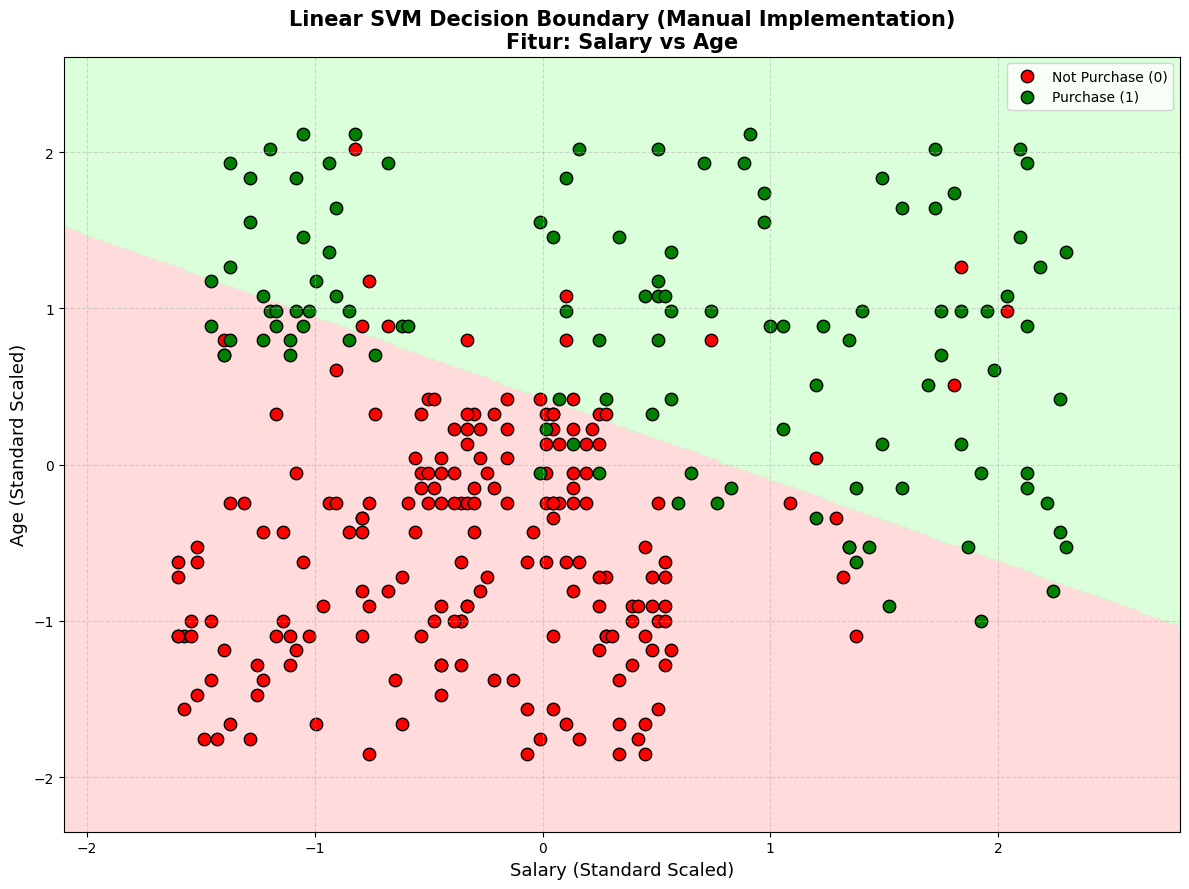

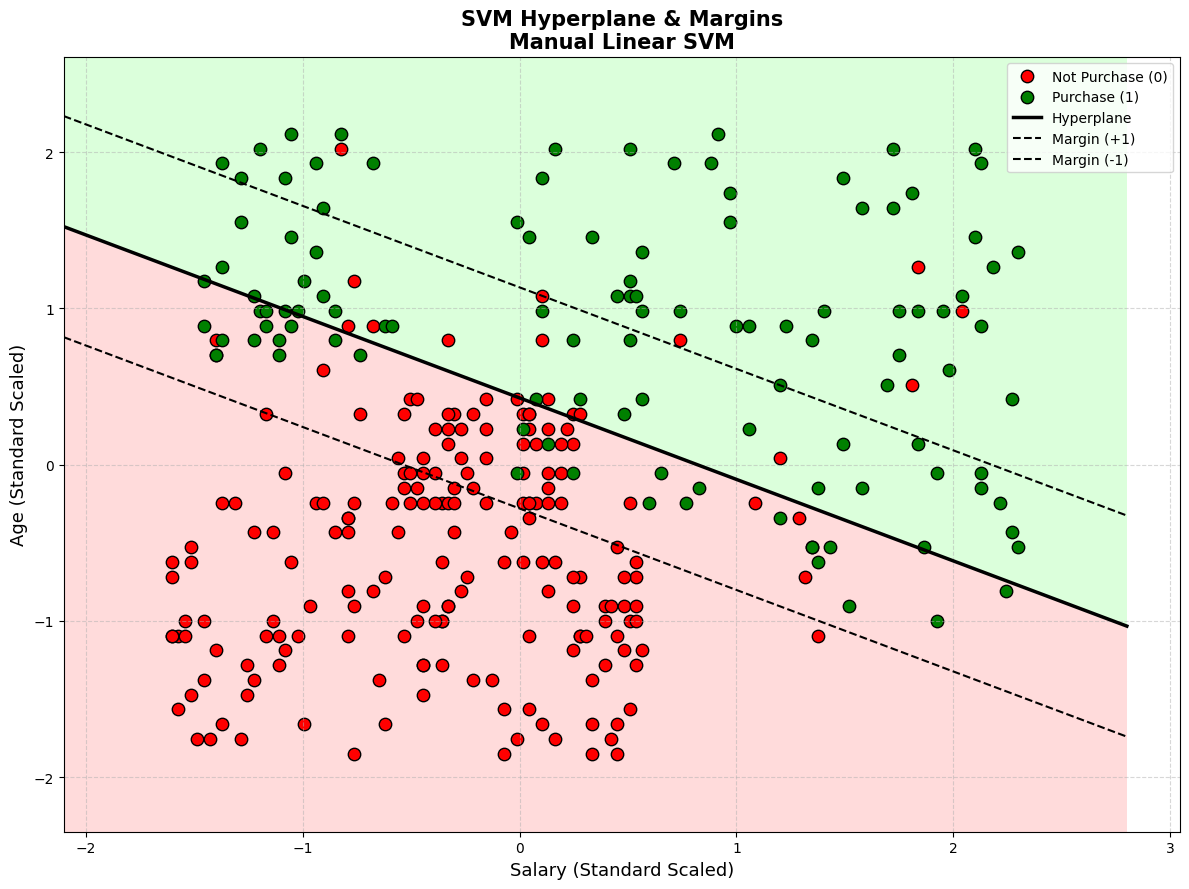

In [537]:
X_train_2d = dataset_training[['Salary', 'Age']].to_numpy()
y_train_2d = dataset_training['Purchase Iphone'].to_numpy()

svm_model_2d = LinearSVManual(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
svm_model_2d.fit(X_train_2d, y_train_2d)

h = 0.02
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = svm_model_2d.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 9))

plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=['#FFCCCC', '#CCFFCC'], alpha=0.7)

mask_0 = y_train_2d == 0
mask_1 = y_train_2d == 1

plt.scatter(X_train_2d[mask_0, 0], X_train_2d[mask_0, 1],
            color='red', edgecolors='black', s=80, linewidth=1, label='Not Purchase (0)')
plt.scatter(X_train_2d[mask_1, 0], X_train_2d[mask_1, 1],
            color='green', edgecolors='black', s=80, linewidth=1, label='Purchase (1)')

plt.xlabel('Salary (Standard Scaled)', fontsize=13)
plt.ylabel('Age (Standard Scaled)', fontsize=13)
plt.title('Linear SVM Decision Boundary (Manual Implementation)\nFitur: Salary vs Age', fontsize=15, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

w = svm_model_2d.w
b = svm_model_2d.b

if abs(w[1]) < 1e-8:
    print("Tidak bisa plot hyperplane: pembagian dengan nol.")
else:
    slope = -w[0] / w[1]
    intercept = b / w[1]

    plt.figure(figsize=(12, 9))

    plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=['#FFCCCC', '#CCFFCC'], alpha=0.7)

    plt.scatter(X_train_2d[mask_0, 0], X_train_2d[mask_0, 1],
                color='red', edgecolors='black', s=80, linewidth=1, label='Not Purchase (0)')
    plt.scatter(X_train_2d[mask_1, 0], X_train_2d[mask_1, 1],
                color='green', edgecolors='black', s=80, linewidth=1, label='Purchase (1)')

    x_vals = np.linspace(x_min, x_max, 100)
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, 'k-', linewidth=2.5, label='Hyperplane')

    y_margin_pos = slope * x_vals + (b + 1) / w[1]
    y_margin_neg = slope * x_vals + (b - 1) / w[1]
    plt.plot(x_vals, y_margin_pos, 'k--', linewidth=1.5, label='Margin (+1)')
    plt.plot(x_vals, y_margin_neg, 'k--', linewidth=1.5, label='Margin (-1)')

    plt.xlabel('Salary (Standard Scaled)', fontsize=13)
    plt.ylabel('Age (Standard Scaled)', fontsize=13)
    plt.title('SVM Hyperplane & Margins\nManual Linear SVM', fontsize=15, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## ***C. Evaluasi Model***

#### *a. Confusion Matrix*

In [538]:
svm_model_full = LinearSVManual(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
svm_model_full.fit(X_train, y_train)  
y_pred = svm_model_full.predict(X_test)

def compute_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))  # True Positive
    tn = np.sum((y_true == 0) & (y_pred == 0))  # True Negative
    fp = np.sum((y_true == 0) & (y_pred == 1))  # False Positive
    fn = np.sum((y_true == 1) & (y_pred == 0))  # False Negative
    return np.array([[tn, fp],
                     [fn, tp]])

cm = compute_confusion_matrix(y_test, y_pred)

print("=== Confusion Matrix ===")
print(cm)

=== Confusion Matrix ===
[[41  7]
 [ 8 20]]


In [539]:
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n=== Metrik Evaluasi ===")
print(f"Akurasi   : {accuracy:.4f}")
print(f"Presisi   : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1_score:.4f}")


=== Metrik Evaluasi ===
Akurasi   : 0.8026
Presisi   : 0.7407
Recall    : 0.7143
F1-Score  : 0.7273


#### *b. Bias and Variance Model*

In [540]:
np.random.seed(42)
n_models = 10
n_train_samples = len(X_train)
model_predictions = []

for i in range(n_models):
    indices = np.random.choice(n_train_samples, size=n_train_samples, replace=True)
    X_boot = X_train[indices]
    y_boot = y_train[indices]

    model = LinearSVManual(learning_rate=0.001, lambda_param=0.01, n_iters=500)
    model.fit(X_boot, y_boot)

    y_pred_boot = model.predict(X_test)
    model_predictions.append(y_pred_boot)

model_predictions = np.array(model_predictions)
avg_predictions = np.mean(model_predictions, axis=0)
y_true_float = y_test.astype(float)

bias_squared = np.mean((avg_predictions - y_true_float)**2)
variance = np.mean(np.var(model_predictions, axis=0))

print("\n=== ESTIMASI BIAS & VARIANCE ===")
print(f"Bias^2 (rata-rata): {bias_squared:.6f}")
print(f"Variance (rata-rata): {variance:.6f}")


=== ESTIMASI BIAS & VARIANCE ===
Bias^2 (rata-rata): 0.171316
Variance (rata-rata): 0.036579


#### *c. K-Fold Cross Validation*

In [541]:
def evaluation_metric(y_true, y_pred, average='micro'):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return accuracy, precision, recall, f1


def stratified_k_fold(X, y, model, k=5):
    classes = np.unique(y)
    folds = [[] for _ in range(k)]

    # Bagi tiap kelas ke dalam k fold secara merata
    for cls in classes:
        idx = np.where(y == cls)[0]
        np.random.shuffle(idx)
        split = np.array_split(idx, k)
        for i in range(k):
            folds[i].extend(split[i])

    # Simpan metrik per fold
    accs, precs, recs, f1s = [], [], [], []

    print(f"=== {k}-FOLD STRATIFIED CROSS VALIDATION ===\n")

    for i in range(k):
        test_idx = np.array(folds[i])
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])

        # Pastikan bentuk 1D
        train_idx = train_idx.astype(int)
        test_idx = test_idx.astype(int)

        # Latih model
        model.fit(X[train_idx], y[train_idx])

        # Prediksi
        y_pred = model.predict(X[test_idx])

        # Evaluasi
        acc, prec, rec, f1 = evaluation_metric(y[test_idx], y_pred)

        # Simpan
        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)

        print(f"Fold {i+1}: Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

    # Hitung statistik
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    mean_prec = np.mean(precs)
    mean_rec = np.mean(recs)
    mean_f1 = np.mean(f1s)

    print(f"\nRATA-RATA METRIK {k}-FOLD:")
    print(f"   Akurasi   : {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"   Presisi   : {mean_prec:.4f}")
    print(f"   Recall    : {mean_rec:.4f}")
    print(f"   F1-Score  : {mean_f1:.4f}")

    return mean_acc, std_acc, mean_f1  # return F1 juga buat bandingin nanti

In [542]:
# Siapkan model
svm_cv_model = LinearSVManual(learning_rate=0.001, lambda_param=0.01, n_iters=1000)

# Jalankan CV
mean_acc, std_acc, mean_f1 = stratified_k_fold(X_train, y_train, svm_cv_model, k=5)

=== 5-FOLD STRATIFIED CROSS VALIDATION ===

Fold 1: Acc=0.9194 | Prec=1.0000 | Rec=0.7826 | F1=0.8780
Fold 2: Acc=0.8226 | Prec=0.8333 | Rec=0.6522 | F1=0.7317
Fold 3: Acc=0.8500 | Prec=0.7600 | Rec=0.8636 | F1=0.8085
Fold 4: Acc=0.7833 | Prec=0.7368 | Rec=0.6364 | F1=0.6829
Fold 5: Acc=0.8500 | Prec=0.8824 | Rec=0.6818 | F1=0.7692

RATA-RATA METRIK 5-FOLD:
   Akurasi   : 0.8451 ± 0.0445
   Presisi   : 0.8425
   Recall    : 0.7233
   F1-Score  : 0.7741
